##  Example 1: Predicting House Prices (Regression)

#### CALIFORNIA HOUSING — REGRESSION


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


In [4]:
## Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## 1. LOAD DATA

In [6]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
X = housing.data.values.astype(np.float32)
y = housing.target.values.astype(np.float32)
print(f"Features: {housing.feature_names}")
print(f"Shape: X={X.shape} | y={y.shape}")
print(f"Target range: {y.min():.2f} – {y.max():.2f} ($100k)")


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape: X=(20640, 8) | y=(20640,)
Target range: 0.15 – 5.00 ($100k)


# ── 2. PREPROCESSING ──────────────────────────────────────

- Training set → used to learn the model.
- Validation set → used to make decisions about the model/hyperparameters.
- Test set → used only at the very end to estimate real-world performance.

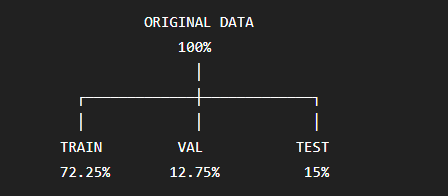

In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(
X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
X_temp, y_temp, test_size=0.15, random_state=42
)

from sklearn.model_selection import train_test_split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)
print(f"\nTrain: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")


Train: 14912 | Val: 2632 | Test: 3096


# ── 4. MODEL ──────────────────────────────────────────────

In [27]:
def build_house_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name='features')

    x = keras.layers.Dense(256)(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(128)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    x = keras.layers.Dense(64)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.1)(x)

    outputs = keras.layers.Dense(1, name='price_output')(x)
    return keras.Model(inputs, outputs, name='HousePriceANN')

In [17]:
model = build_house_model(input_dim=8)
model.summary()


Model: "HousePriceANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ price_output (Dense)                 │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 44,417 (173.50 KB)

 Non-trainable params: 896 (3.50 KB)

# ── 4. COMPILE ────────────────────────────────────────────

In [18]:
model.compile(
optimizer=keras.optimizers.Adam(learning_rate=1e-3),
loss='mse',
metrics=['mae']
)


## A callback is basically:

A piece of code that Keras calls automatically at specific points during training.

# Callbacks in Neural Network Training

## 1. What is a Callback?

A **callback** is a piece of code that Keras automatically runs at specific points during training.

When we call:

```python
model.fit(...)
```

the model trains repeatedly:

```text
Forward Pass
     ↓
Calculate Loss
     ↓
Backpropagation
     ↓
Update Weights
     ↓
Next Epoch
```

Callbacks **watch this process** and can take actions when certain conditions occur.

### Simple analogy

Think of training a neural network like a student preparing for an exam:

* **Neural Network** → Student
* **Validation Loss** → Practice-test score
* **EarlyStopping** → Teacher saying "Stop studying; you're no longer improving."
* **ReduceLROnPlateau** → Teacher saying "Slow down and study more carefully."
* **ModelCheckpoint** → Saving the student's best exam result.

---

# 2. Our Three Callbacks

```python
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        "best_house_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    )
]
```

Each callback has a **different responsibility**:

| Callback            | Main Job                                      |
| ------------------- | --------------------------------------------- |
| `EarlyStopping`     | Stop training when improvement stops          |
| `ReduceLROnPlateau` | Reduce learning rate when progress gets stuck |
| `ModelCheckpoint`   | Save the best model to disk                   |

---

# 3. EarlyStopping

```python
keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)
```

### What does it do?

It asks:

> **"Are we still improving?"**

We monitor:

```python
monitor="val_loss"
```

because validation loss tells us how well the model is performing on **unseen data**.

---

## `patience=15`

This means:

> If `val_loss` does not improve for **15 consecutive epochs**, stop training.

It does **NOT** mean:

> Train for only 15 epochs.

For example:

```text
Epoch 20 → val_loss = 100  ← Best
Epoch 21 → 103
Epoch 22 → 105
Epoch 23 → 102
...
Epoch 35 → still no improvement
                 ↓
             STOP
```

### Why not stop immediately?

Training can fluctuate:

```text
100 → 103 → 98
```

The model got worse temporarily but then improved.

`patience` gives the model time to recover.

---

## `restore_best_weights=True`

Suppose:

```text
Epoch 20 → val_loss = 100  ← BEST
...
Epoch 35 → val_loss = 130  ← Training stops
```

Without `restore_best_weights`, the model could remain with the weights from epoch 35.

With:

```python
restore_best_weights=True
```

Keras restores the weights from **epoch 20**, where the validation loss was best.

```text
Training stops
      ↓
Restore best weights
      ↓
Use Epoch 20 model
```

---

# 4. ReduceLROnPlateau

```python
keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6
)
```

This callback asks:

> **"Are we stuck? If so, should we take smaller learning steps?"**

---

## Why reduce the learning rate?

Remember:

```python
Adam(learning_rate=5e-4)
```

The learning rate controls how large the optimizer's weight updates are.

Think of finding the bottom of a valley:

```text
Large steps:

       \       /
        \     /
         \   /
          \_/
```

Large steps can move quickly but may jump over the best point.

Smaller steps:

```text
       \       /
        \     /
         \   /
          \_/
          ↓
       precise
```

can help the model make finer adjustments.

---

## `factor=0.5`

If the current learning rate is:

```text
0.0005
```

and the model gets stuck:

```text
0.0005 × 0.5
=
0.00025
```

If it gets stuck again:

```text
0.00025 × 0.5
=
0.000125
```

So:

```text
0.0005
   ↓
0.00025
   ↓
0.000125
   ↓
0.0000625
   ↓
...
```

---

## `patience=7`

This means:

> If validation loss does not improve for 7 epochs, reduce the learning rate.

So:

```text
7 epochs without improvement
             ↓
       Reduce learning rate
             ↓
       Continue training
```

The model gets another chance to improve.

---

## `min_lr=1e-6`

This prevents the learning rate from becoming extremely small.

```text
minimum learning rate = 0.000001
```

Keras will not reduce it below this value.

---

# 5. ModelCheckpoint

```python
keras.callbacks.ModelCheckpoint(
    "best_house_model.keras",
    monitor="val_loss",
    save_best_only=True
)
```

This callback asks:

> **"Is this the best model we've seen so far?"**

If yes:

```text
SAVE MODEL
```

---

## Example

```text
Epoch       val_loss

1             500
2             400
3             350
4             300   ← Best
5             320
6             340
7             330
```

The model is saved whenever a new best value is found:

```text
Epoch 1 → SAVE
Epoch 2 → SAVE
Epoch 3 → SAVE
Epoch 4 → SAVE ⭐
Epoch 5 → Don't save
Epoch 6 → Don't save
Epoch 7 → Don't save
```

The best model is stored as:

```text
best_house_model.keras
```

---

# 6. Why `ModelCheckpoint` if we already have `restore_best_weights`?

They solve **different problems**.

### `restore_best_weights=True`

Restores the best weights **inside the current training process**.

### `ModelCheckpoint`

Saves the best model **to disk**.

```text
restore_best_weights
        ↓
Best weights in memory


ModelCheckpoint
        ↓
best_house_model.keras
        ↓
Saved on disk
```

Therefore, even after your Python program stops, you can load the saved model:

```python
model = keras.models.load_model(
    "best_house_model.keras"
)
```

---

# 7. Why use THREE callbacks instead of ONE?

You could technically write one giant custom callback that does everything.

But the three callbacks have **different responsibilities**.

```text
EarlyStopping
      ↓
"Should we STOP?"

ReduceLROnPlateau
      ↓
"Should we SLOW DOWN?"

ModelCheckpoint
      ↓
"Should we SAVE?"
```

This follows a useful software-engineering principle:

> **One component → one main responsibility.**

Using separate callbacks makes the training system:

* Easier to understand
* Easier to configure
* Easier to debug
* Easier to reuse

---

# 8. How They Work Together

Imagine:

```text
Epoch 1
   ↓
Model improves
   ↓
Checkpoint saves model

Epoch 2
   ↓
Model improves
   ↓
Checkpoint saves model

...

Model stops improving
   ↓
7 epochs without improvement
   ↓
Reduce learning rate
   ↓
Continue training

Model improves again
   ↓
Checkpoint saves new best model

...

15 epochs without improvement
   ↓
EarlyStopping
   ↓
STOP

restore_best_weights=True
   ↓
Restore best weights
```

So the callbacks work as a **team**:

```text
                 TRAINING
                    │
                    ▼
              Validation Loss
                    │
          ┌─────────┼─────────┐
          │         │         │
          ▼         ▼         ▼
      EarlyStop  ReduceLR  Checkpoint
          │         │         │
          ▼         ▼         ▼
        STOP      SLOW      SAVE
```

---

# 9. The Three Callbacks — Memorize This

### 🛑 EarlyStopping

> **STOP** when the model is no longer improving.

### 🐢 ReduceLROnPlateau

> **SLOW DOWN** when the model gets stuck.

### 💾 ModelCheckpoint

> **SAVE** whenever the model reaches a new best performance.

```text
        STOP
         ↑
EarlyStopping

        SLOW
         ↑
ReduceLROnPlateau

        SAVE
         ↑
ModelCheckpoint
```

---

# 10. The Big Picture

Callbacks do **not** teach the model how to learn.

The optimizer, loss function, and backpropagation handle learning.

Callbacks manage the **training process**.

```text
              NEURAL NETWORK TRAINING

                     DATA
                      ↓
                Neural Network
                      ↓
                  Prediction
                      ↓
                     Loss
                      ↓
               Backpropagation
                      ↓
                    Adam
                      ↓
               Update Weights
                      ↓
                   EPOCH
                      ↓
              ┌───────┼────────┐
              ↓       ↓        ↓
          STOP?     SLOW?     SAVE?
              ↓       ↓        ↓
        EarlyStop  ReduceLR  Checkpoint
```

### Final mental model

> **The network learns.
> The loss measures its mistakes.
> The optimizer changes its weights.
> Callbacks supervise the training process.**


In [20]:
callbacks = [
keras.callbacks.EarlyStopping(
monitor='val_loss', patience=15,
restore_best_weights=True, verbose=1
),
keras.callbacks.ReduceLROnPlateau(
monitor='val_loss', factor=0.5, patience=7,
min_lr=1e-6, verbose=1
),
keras.callbacks.ModelCheckpoint(
'best_house_model.keras', monitor='val_loss',
save_best_only=True, verbose=0
)
]

# ── 6. TRAIN ──────────────────

In [21]:
history = model.fit(
X_train, y_train,
epochs=200, batch_size=256,
validation_data=(X_val, y_val),
callbacks=callbacks, verbose=1
)


Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 2.4285 - mae: 1.2078 - val_loss: 2.9133 - val_mae: 1.4025 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7519 - mae: 0.6340 - val_loss: 1.7479 - val_mae: 1.0052 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.6421 - mae: 0.5895 - val_loss: 1.2261 - val_mae: 0.8010 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5931 - mae: 0.5642 - val_loss: 0.8995 - val_mae: 0.6616 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5514 - mae: 0.5456 - val_loss: 0.7199 - val_mae: 0.5779 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.5253 - mae: 0.5318 - val_loss: 0.5603 - val_mae: 0.4975 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.5077 - mae: 0.5206 - val_loss: 0.5187 - val_mae: 0.4797 - learning_rate: 0.0010
Epoch 

# ── 7. EVALUATE ───────────────────────────────────────────

In [22]:
results = model.evaluate(X_test, y_test, verbose=0)
print(f"\n=== TEST RESULTS ===")
print(f"MSE: {results[0]:.4f}")
print(f"MAE: {results[1]:.4f} (${results[1]*100:.0f}k average error)")
y_pred = model.predict(X_test, verbose=0).flatten()
r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.4f} (1.0 = perfect)")


=== TEST RESULTS ===
MSE: 0.5007
MAE: 0.4686 ($47k average error)


NameError: name 'r2_score' is not defined

# ── 8. VISUALIZE ──────────────────────────────────────────


NameError: name 'r2' is not defined

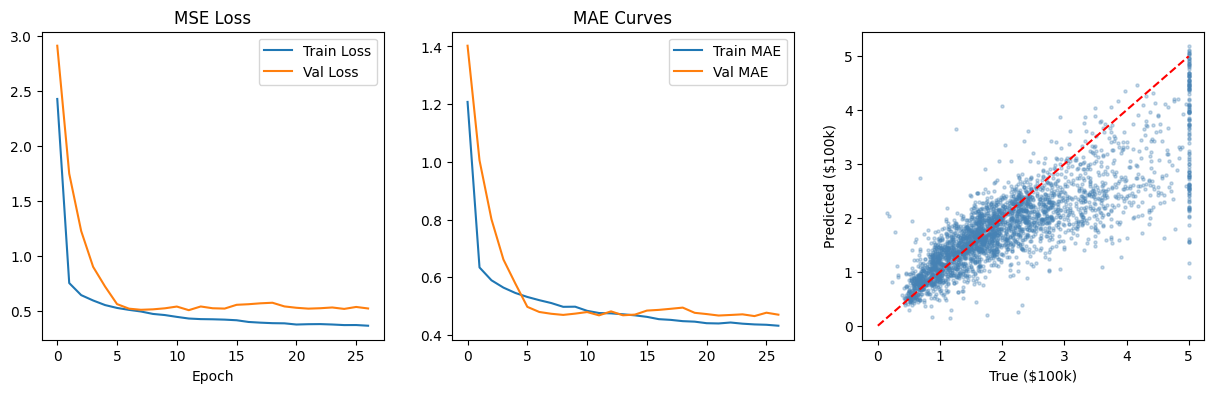

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curves')
axes[1].legend()
axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
axes[2].plot([0, 5], [0, 5], 'r--', label='Perfect')
axes[2].set_xlabel('True ($100k)')
axes[2].set_ylabel('Predicted ($100k)')
axes[2].set_title(f'Predicted vs Actual R²={r2:.3f}')
axes[2].legend()
plt.tight_layout()
plt.savefig('house_price_results.png', dpi=150)
plt.show()